/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/shapely/predicates.py:806: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)
/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/skalidin/miniconda3/envs/e

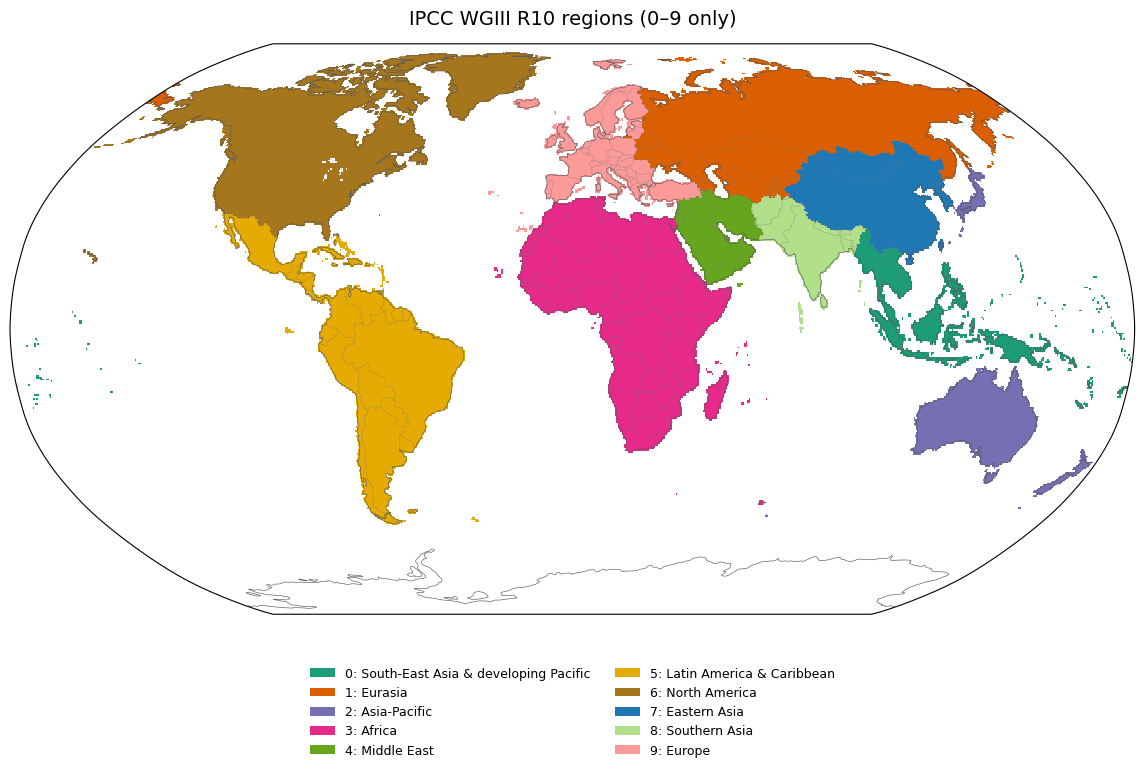

Output files will be written to:\n- r10_regions_map_nature_style.png\n- r10_regions_map_nature_style.pdf


In [3]:

# R10 world regions map
#This notebook reads `r10masks_fractional.nc`, keeps only indices `0-9`, assigns each land grid cell to its dominant R10 region, and exports a publication-style global map as high-resolution PNG and PDF.



# If needed once in JupyterLab:
# %pip install xarray netCDF4 matplotlib cartopy

from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Run the notebook from the same folder as the NetCDF file
nc_path = Path("r10masks_fractional.nc")

# Or use the full path directly:
# nc_path = Path("/Users/skalidin/Documents/imperial/Reading_Research/ESM_2025/DATA_carbon_AR6_Imputation/r10masks_fractional.nc")

region_names = [
    "South-East Asia & developing Pacific",
    "Eurasia",
    "Asia-Pacific",
    "Africa",
    "Middle East",
    "Latin America & Caribbean",
    "North America",
    "Eastern Asia",
    "Southern Asia",
    "Europe",
]

region_colors = [
    "#1b9e77", "#d95f02", "#7570b3", "#e7298a", "#66a61e",
    "#e6ab02", "#a6761d", "#1f78b4", "#b2df8a", "#fb9a99"
]

# ---------------------------
# Load the NetCDF file
# ---------------------------
ds = xr.open_dataset(nc_path)

# Find the 3D mask variable automatically
candidate_vars = [v for v in ds.data_vars if ds[v].ndim == 3]
if not candidate_vars:
    raise ValueError("No 3D regional mask variable found in the NetCDF file.")

mask_var = "region" if "region" in ds.data_vars else candidate_vars[0]
da = ds[mask_var]

reg_dim, lat_dim, lon_dim = da.dims[:3]

# Keep only regions 0-9 (ignore 10 = World)
frac = da.isel({reg_dim: slice(0, 10)})

# Assign each grid cell to the dominant region
dominant_region = frac.argmax(dim=reg_dim)
land_fraction = frac.sum(dim=reg_dim)
dominant_region = dominant_region.where(land_fraction > 0)

lon = ds[lon_dim].values
lat = ds[lat_dim].values

# Wrap longitude to [-180, 180] for cleaner world plotting
if lon.max() > 180:
    lon_wrapped = ((lon + 180) % 360) - 180
    order = np.argsort(lon_wrapped)
    lon = lon_wrapped[order]
    dominant_region = dominant_region.isel({lon_dim: order})

# Ensure latitude runs south -> north
if lat[0] > lat[-1]:
    lat = lat[::-1]
    dominant_region = dominant_region.isel({lat_dim: slice(None, None, -1)})

# ---------------------------
# Plot
# ---------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.linewidth": 0.8,
})

cmap = ListedColormap(region_colors)
cmap.set_bad("white")
norm = BoundaryNorm(np.arange(-0.5, 10.5, 1), cmap.N)

fig = plt.figure(figsize=(14, 7.5), facecolor="white")
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.set_facecolor("#edf3f9")

ax.pcolormesh(
    lon,
    lat,
    dominant_region,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    shading="auto",
    rasterized=True,
)

ax.add_feature(cfeature.OCEAN, facecolor="#edf3f9", zorder=0)
ax.coastlines(linewidth=0.45, color="0.35")
ax.add_feature(cfeature.BORDERS, linewidth=0.2, edgecolor="0.45")

ax.set_title("IPCC WGIII R10 regions (0–9 only)", fontsize=14, pad=14)

legend_handles = [
    Patch(facecolor=region_colors[i], edgecolor="none", label=f"{i}: {region_names[i]}")
    for i in range(10)
]

ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.27),
    ncol=2,
    frameon=False,
    fontsize=9,
)

plt.tight_layout()

# Save high-resolution outputs for a journal figure
out_png = nc_path.with_name("r10_regions_map_nature_style.png")
out_pdf = nc_path.with_name("r10_regions_map_nature_style.pdf")

plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.savefig(out_pdf, dpi=600, bbox_inches="tight")
plt.show()

print(f"Output files will be written to:\\n- {out_png}\\n- {out_pdf}")


/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/shapely/predicates.py:806: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)
/Users/skalidin/miniconda3/envs/es

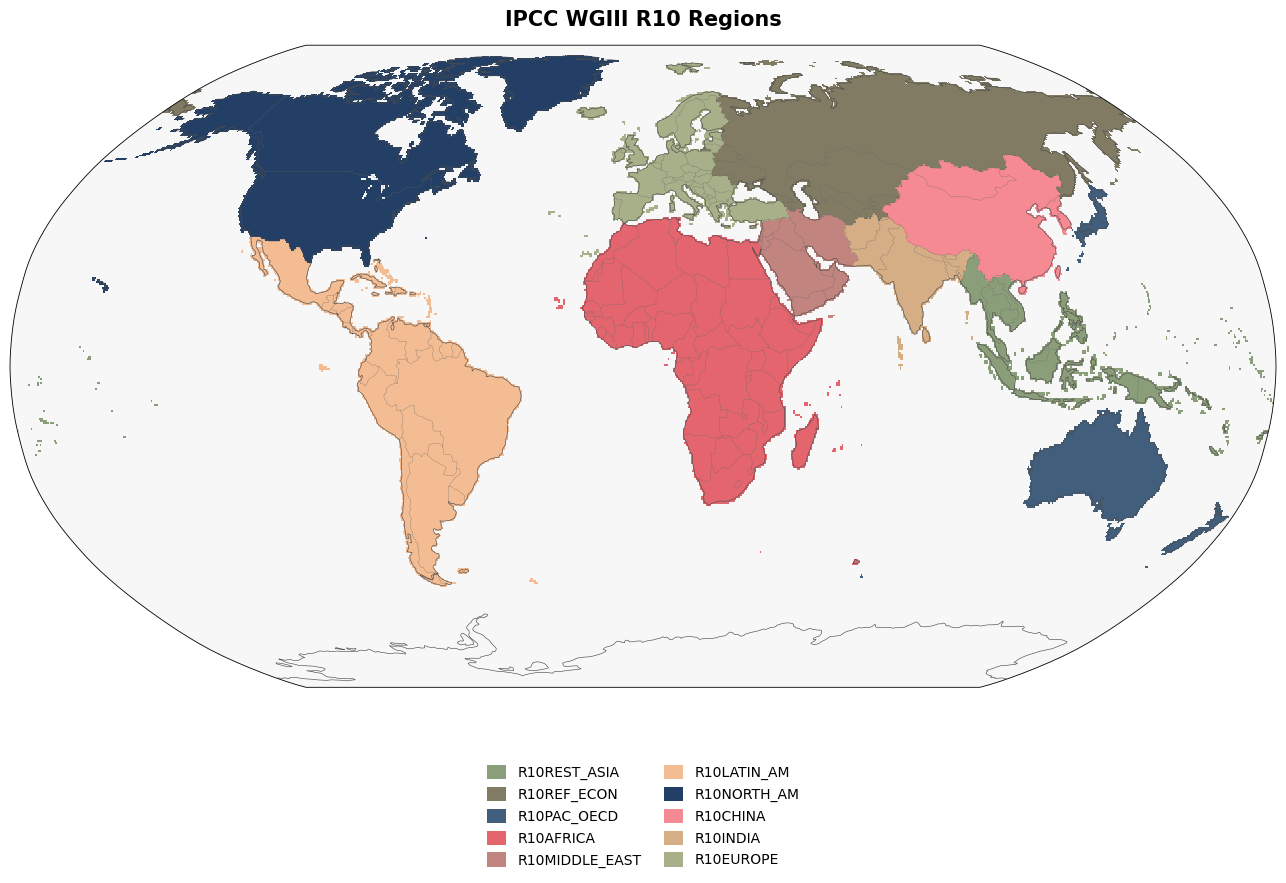

Saved:
- r10_regions_map_ipcc_style.png
- r10_regions_map_ipcc_style.pdf


In [4]:
# %pip install xarray netCDF4 matplotlib cartopy

from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --------------------------------------------------
# Input file
# --------------------------------------------------
nc_path = Path("r10masks_fractional.nc")

# --------------------------------------------------
# R10 labels matched to the NetCDF metadata (0-9 only)
# --------------------------------------------------
region_names = [
    "R10REST_ASIA",   # 0 = South-East Asia and developing Pacific
    "R10REF_ECON",    # 1 = Eurasia
    "R10PAC_OECD",    # 2 = Asia-Pacific
    "R10AFRICA",      # 3 = Africa
    "R10MIDDLE_EAST", # 4 = Middle East
    "R10LATIN_AM",    # 5 = Latin America and Caribbean
    "R10NORTH_AM",    # 6 = North America
    "R10CHINA",       # 7 = Eastern Asia
    "R10INDIA",       # 8 = Southern Asia
    "R10EUROPE",      # 9 = Europe
]

# --------------------------------------------------
# Nature / IPCC-like muted palette from your swatch
# --------------------------------------------------
region_colors = [
    "#8B9E7A",  # R10REST_ASIA   muted sage green
    "#807B62",  # R10REF_ECON    olive-grey
    "#415E7D",  # R10PAC_OECD    slate blue
    "#E4656E",  # R10AFRICA      muted coral-red
    "#C2847E",  # R10MIDDLE_EAST dusty rose-brown
    "#F4BC92",  # R10LATIN_AM    soft apricot
    "#233F65",  # R10NORTH_AM    deep blue
    "#F58A93",  # R10CHINA       rose pink
    "#D5AE85",  # R10INDIA       warm tan
    "#A7B089",  # R10EUROPE      pale olive green
]

# --------------------------------------------------
# Load dataset
# --------------------------------------------------
ds = xr.open_dataset(nc_path)

# The main regional mask variable in this file is r10_code(region, latitude, longitude)
var_name = "r10_code" if "r10_code" in ds.data_vars else list(ds.data_vars)[0]
da = ds[var_name]

reg_dim, lat_dim, lon_dim = da.dims[:3]

# Keep only 0-9; exclude 10 = World
frac = da.isel({reg_dim: slice(0, 10)})

# Dominant region per grid cell
dominant_region = frac.argmax(dim=reg_dim)

# Mask ocean / non-land cells
land_fraction = frac.sum(dim=reg_dim)
dominant_region = dominant_region.where(land_fraction > 0)

lat = ds[lat_dim].values
lon = ds[lon_dim].values

# Convert longitudes from 0..360 to -180..180 if needed
if lon.max() > 180:
    lon_wrapped = ((lon + 180) % 360) - 180
    order = np.argsort(lon_wrapped)
    lon = lon_wrapped[order]
    dominant_region = dominant_region.isel({lon_dim: order})

# Ensure latitude is increasing for plotting
if lat[0] > lat[-1]:
    lat = lat[::-1]
    dominant_region = dominant_region.isel({lat_dim: slice(None, None, -1)})

# --------------------------------------------------
# Plot styling
# --------------------------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.linewidth": 0.6,
})

cmap = ListedColormap(region_colors)
cmap.set_bad("#F7F7F7")
norm = BoundaryNorm(np.arange(-0.5, 10.5, 1), cmap.N)

fig = plt.figure(figsize=(14, 8), facecolor="white")
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.set_facecolor("#F7F7F7")

mesh = ax.pcolormesh(
    lon,
    lat,
    dominant_region,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    shading="auto",
    rasterized=True,
    zorder=2
)

ax.add_feature(cfeature.OCEAN, facecolor="#F7F7F7", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="none", zorder=1)
ax.coastlines(linewidth=0.45, color="#4D4D4D", zorder=3)
ax.add_feature(cfeature.BORDERS, linewidth=0.20, edgecolor="#666666", zorder=3)

ax.set_title(
    "IPCC WGIII R10 Regions",
    fontsize=15,
    weight="bold",
    pad=14
)

legend_handles = [
    Patch(facecolor=region_colors[i], edgecolor="none", label=region_names[i])
    for i in range(10)
]

legend = ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=2,
    frameon=False,
    fontsize=10,
    handlelength=1.4,
    handleheight=1.2,
    columnspacing=1.6
)

plt.tight_layout()

# --------------------------------------------------
# Save figure
# --------------------------------------------------
out_png = nc_path.with_name("r10_regions_map_ipcc_style.png")
out_pdf = nc_path.with_name("r10_regions_map_ipcc_style.pdf")

plt.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig(out_pdf, dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved:\n- {out_png}\n- {out_pdf}")

/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/skalidin/miniconda3/envs/esm2025/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in bu

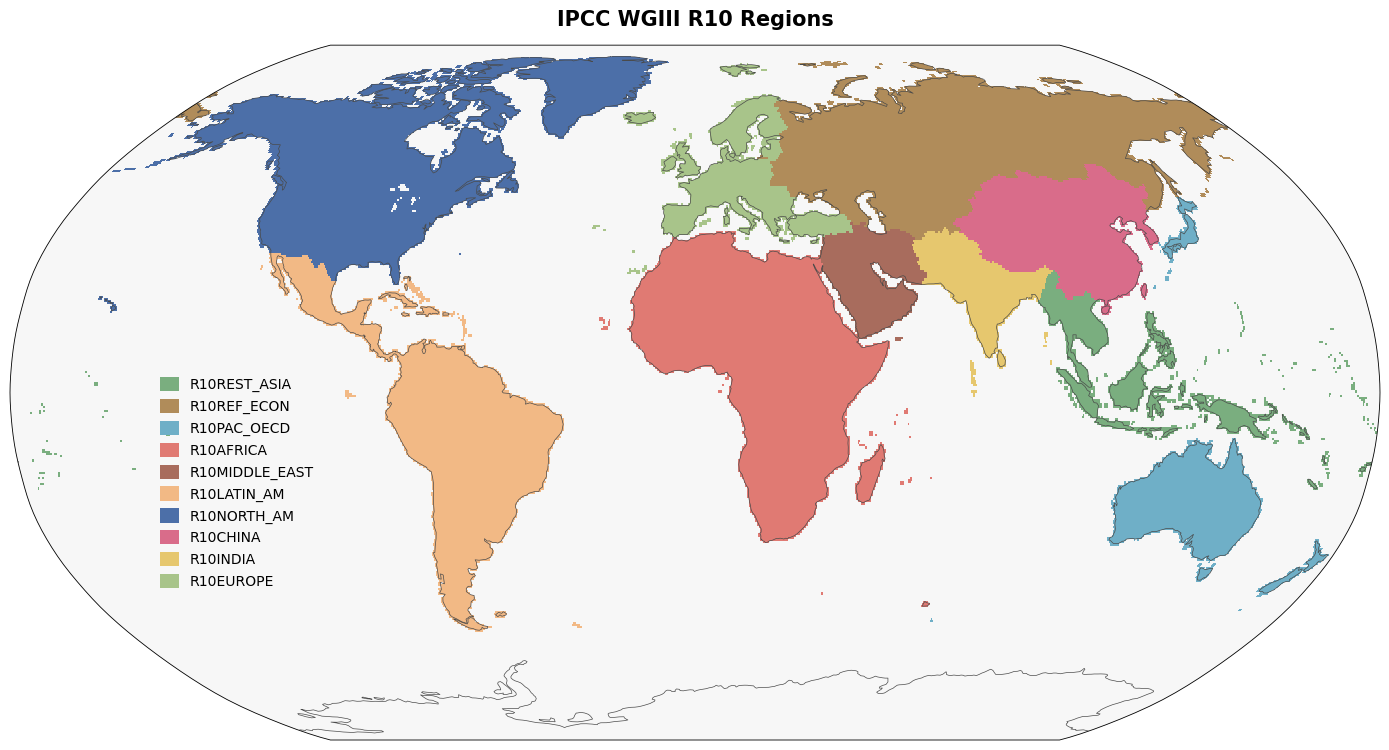

Saved:
- r10_regions_map_distinct_colors.png
- r10_regions_map_distinct_colors.pdf


In [11]:
#This code is used to plot R10 regions used in this study from IPCC WG3 classification r10 regions mask (Smith et al., 2023)
# pip install xarray netCDF4 matplotlib cartopy if needed

from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --------------------------------------------------
# Input file
# --------------------------------------------------
nc_path = Path("r10masks_fractional.nc")

# --------------------------------------------------
# Region names matched to the NetCDF file (0-9 only)
# --------------------------------------------------
region_names = [
    "R10REST_ASIA",   # 0 = South-East Asia and developing Pacific
    "R10REF_ECON",    # 1 = Eurasia
    "R10PAC_OECD",    # 2 = Asia-Pacific
    "R10AFRICA",      # 3 = Africa
    "R10MIDDLE_EAST", # 4 = Middle East
    "R10LATIN_AM",    # 5 = Latin America and Caribbean
    "R10NORTH_AM",    # 6 = North America
    "R10CHINA",       # 7 = Eastern Asia
    "R10INDIA",       # 8 = Southern Asia
    "R10EUROPE",      # 9 = Europe
]

# --------------------------------------------------
# Distinct muted palette
# Chosen to avoid near-duplicates
# --------------------------------------------------
region_colors = [
    "#7AAE7F",  # R10REST_ASIA   muted green
    "#B08C5A",  # R10REF_ECON    brown/khaki
    "#6FAFC7",  # R10PAC_OECD    light blue-teal
    "#E07A73",  # R10AFRICA      muted coral
    "#A86C5D",  # R10MIDDLE_EAST earthy brown-red
    "#F2B985",  # R10LATIN_AM    warm peach
    "#4C6FA8",  # R10NORTH_AM    deeper blue
    "#D96C8A",  # R10CHINA       rose
    "#E6C76E",  # R10INDIA       muted mustard
    "#A8C48A",  # R10EUROPE      light olive
]

# --------------------------------------------------
# Load dataset
# --------------------------------------------------
ds = xr.open_dataset(nc_path)

# Main variable from the verified file metadata
var_name = "r10_code" if "r10_code" in ds.data_vars else list(ds.data_vars)[0]
da = ds[var_name]

reg_dim, lat_dim, lon_dim = da.dims[:3]

# Keep only 0-9, excluding 10 = World
frac = da.isel({reg_dim: slice(0, 10)})

# Dominant region assignment for each grid cell
dominant_region = frac.argmax(dim=reg_dim)

# Mask non-land/ocean cells
land_fraction = frac.sum(dim=reg_dim)
dominant_region = dominant_region.where(land_fraction > 0)

lat = ds[lat_dim].values
lon = ds[lon_dim].values

# Convert longitudes to -180..180 if needed
if lon.max() > 180:
    lon_wrapped = ((lon + 180) % 360) - 180
    order = np.argsort(lon_wrapped)
    lon = lon_wrapped[order]
    dominant_region = dominant_region.isel({lon_dim: order})

# Ensure latitudes increase from south to north
if lat[0] > lat[-1]:
    lat = lat[::-1]
    dominant_region = dominant_region.isel({lat_dim: slice(None, None, -1)})

# --------------------------------------------------
# Plot style
# --------------------------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.linewidth": 0.6,
})

cmap = ListedColormap(region_colors)
cmap.set_bad("#F7F7F7")
norm = BoundaryNorm(np.arange(-0.5, 10.5, 1), cmap.N)

fig = plt.figure(figsize=(14, 8), facecolor="white")
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.set_facecolor("#F7F7F7")

ax.pcolormesh(
    lon,
    lat,
    dominant_region,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    shading="auto",
    rasterized=True,
    zorder=2
)

ax.add_feature(cfeature.OCEAN, facecolor="#F7F7F7", zorder=0)
ax.coastlines(linewidth=0.5, color="#4A4A4A", zorder=3)



ax.set_title("IPCC WGIII R10 Regions", fontsize=15, weight="bold", pad=14)

legend_handles = [
    Patch(facecolor=region_colors[i], edgecolor="none", label=region_names[i])
    for i in range(10)
]

ax.legend(
    handles=legend_handles,
    loc="lower left",
    bbox_to_anchor=(0.1, 0.2),
    ncol=1,
    frameon=False,
    fontsize=10,
    handlelength=1.4,
    handleheight=1.2,
    columnspacing=1.6
)

plt.tight_layout()

# --------------------------------------------------
# Save output
# --------------------------------------------------
out_png = nc_path.with_name("r10_regions_map_distinct_colors.png")
out_pdf = nc_path.with_name("r10_regions_map_distinct_colors.pdf")

plt.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig(out_pdf, dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved:\n- {out_png}\n- {out_pdf}")